### Generate cluster with unsupervised learning
#### 1. Import data from descriptor_data.csv
#### 2. Generate PCA map


In [2]:
#Import all packages and set plots to be embedded inline
import numpy as np
import sklearn.gaussian_process as gp
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import LeaveOneOut, cross_val_score
import plotly.express as px
from sklearn.decomposition import PCA


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, mutual_info_score, adjusted_rand_score





In [3]:
X = pd.read_csv('descriptor_data.csv') 

In [4]:
X

,Name,Metal,Atom_A,Atom_B,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,...,% VBur asymm 2,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8
0,ligand-001-n-n-1,2,23,22,80.01004,2.324,2.324,0.26015,-0.42686,-0.42686,...,0.067555,0.051249,79.276929,75.605665,79.304883,75.750093,4.034663,0.242266,3.866940,0.228289
1,ligand-002-p-p-1,2,16,17,81.08750,2.404,2.406,-0.11874,1.06691,1.06830,...,5.049152,3.262439,81.564480,92.051808,83.060007,82.575475,5.101565,8.190458,6.671636,0.535781
2,ligand-003-p-p-2,3,1,12,88.85482,2.393,2.398,-0.12498,1.08763,1.08260,...,0.099003,0.173546,74.021618,74.375699,95.387626,96.706113,8.866008,10.035408,10.860045,10.669027
3,ligand-004-p-p-3,3,45,1,95.97953,2.432,2.441,-0.09320,1.06382,1.05890,...,0.822307,1.202013,97.623928,96.230898,70.308423,71.878494,11.675363,12.486023,18.496086,13.054417
4,ligand-005-c-n-1,1,2,59,86.57124,2.143,2.295,0.17756,0.22924,-0.40636,...,15.149786,30.368291,64.340291,88.292024,40.775252,96.850540,44.781960,9.821096,17.815878,11.330600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,ligand-528-p-o-179,53,1,2,80.74499,2.414,2.313,0.18627,1.21705,-1.06233,...,11.576360,2.083722,95.112747,82.929556,82.789788,89.489378,14.400857,2.115170,18.957324,34.094297
485,ligand-529-p-o-180,53,1,2,80.24881,2.390,2.340,0.13197,1.24066,-1.05627,...,8.255684,3.116847,90.500373,85.370854,51.010995,73.210958,0.549758,0.004659,3.713194,8.861349
486,ligand-530-p-o-181,53,1,2,80.40515,2.410,2.312,0.18230,1.19697,-1.05361,...,18.377283,1.306839,88.883712,99.166045,91.525345,62.350913,0.069884,10.263697,33.600447,9.741893
487,ligand-531-p-o-182,53,1,2,81.38359,2.388,2.333,0.14962,1.23732,-1.05161,...,11.985184,0.323798,87.453410,73.243571,53.922848,77.888558,0.722139,0.069884,0.055908,9.168841


In [5]:
# Create a boolean mask where any column contains the string 'NaN'
mask = X.apply(lambda x: x.astype(str).str.contains('NaN', na=False)).any(axis=1)

# Get the indices of the rows where the mask is True
nan_indices = X[mask].index
missing_values = X.isnull()

# Get the indices of rows with missing values
rows_with_missing = X[X.isnull().any(axis=1)]

# Print the rows with missing values
print("\nRows with missing values:")
print(rows_with_missing)

# Get the indices of rows with missing values
missing_indices = rows_with_missing.index.tolist()

# Remove that indices by dropping
X = X.dropna()

# Add two columns, one with ligand_id, one with donor_atom_combination
# Extract the 3-digit ligand ID and the donor atom combination
X['ligand_id'] = X['Name'].str.extract(r'ligand-(\d{3})')
X['donor_atom_comb'] = X['Name'].str.extract(r'ligand-\d{3}-([a-z]-[a-z])')

# Capitalize the donor_atom_combination
X['donor_atom_comb'] = X['donor_atom_comb'].str.upper()


Rows with missing values:
                  Name  Metal  Atom_A  Atom_B  A-M-B Angle  M-A Distance  \
0     ligand-001-n-n-1      2      23      22     80.01004         2.324   
460  ligand-495-p-n-41      2       1      31     90.41506         2.438   

     M-B Distance  Metal_NBO    A_NBO    B_NBO  ...  % VBur asymm 2  \
0           2.324    0.26015 -0.42686 -0.42686  ...        0.067555   
460         2.393    0.14665  1.05473 -0.42526  ...        6.676295   

     % VBur asymm 3  % VBur octant 1  % VBur octant 2  % VBur octant 3  \
0          0.051249        79.276929        75.605665        79.304883   
460       17.892751        96.715430        63.203504        97.609952   

     % VBur octant 4  % VBur octant 5  % VBur octant 6  % VBur octant 7  \
0          75.750093         4.034663         0.242266         3.866940   
460        85.953224         6.298919        17.075102         3.964778   

     % VBur octant 8  
0           0.228289  
460        19.590943  

[2 rows x 8

C:\Users\George\AppData\Local\Temp\ipykernel_66892\280842449.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ligand_id'] = X['Name'].str.extract(r'ligand-(\d{3})')
C:\Users\George\AppData\Local\Temp\ipykernel_66892\280842449.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['donor_atom_comb'] = X['Name'].str.extract(r'ligand-\d{3}-([a-z]-[a-z])')
C:\Users\George\AppData\Local\Temp\ipykernel_66892\280842449.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

In [6]:
X

,Name,Metal,Atom_A,Atom_B,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,...,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8,ligand_id,donor_atom_comb
1,ligand-002-p-p-1,2,16,17,81.08750,2.404,2.406,-0.11874,1.06691,1.06830,...,81.564480,92.051808,83.060007,82.575475,5.101565,8.190458,6.671636,0.535781,002,P-P
2,ligand-003-p-p-2,3,1,12,88.85482,2.393,2.398,-0.12498,1.08763,1.08260,...,74.021618,74.375699,95.387626,96.706113,8.866008,10.035408,10.860045,10.669027,003,P-P
3,ligand-004-p-p-3,3,45,1,95.97953,2.432,2.441,-0.09320,1.06382,1.05890,...,97.623928,96.230898,70.308423,71.878494,11.675363,12.486023,18.496086,13.054417,004,P-P
4,ligand-005-c-n-1,1,2,59,86.57124,2.143,2.295,0.17756,0.22924,-0.40636,...,64.340291,88.292024,40.775252,96.850540,44.781960,9.821096,17.815878,11.330600,005,C-N
5,ligand-006-c-n-2,1,2,44,86.23337,2.145,2.253,0.17159,0.23504,-0.40535,...,68.766306,82.636042,51.118151,87.183190,25.987700,0.475214,14.018822,9.122251,006,C-N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,ligand-528-p-o-179,53,1,2,80.74499,2.414,2.313,0.18627,1.21705,-1.06233,...,95.112747,82.929556,82.789788,89.489378,14.400857,2.115170,18.957324,34.094297,528,P-O
485,ligand-529-p-o-180,53,1,2,80.24881,2.390,2.340,0.13197,1.24066,-1.05627,...,90.500373,85.370854,51.010995,73.210958,0.549758,0.004659,3.713194,8.861349,529,P-O
486,ligand-530-p-o-181,53,1,2,80.40515,2.410,2.312,0.18230,1.19697,-1.05361,...,88.883712,99.166045,91.525345,62.350913,0.069884,10.263697,33.600447,9.741893,530,P-O
487,ligand-531-p-o-182,53,1,2,81.38359,2.388,2.333,0.14962,1.23732,-1.05161,...,87.453410,73.243571,53.922848,77.888558,0.722139,0.069884,0.055908,9.168841,531,P-O


In [7]:
X.columns

Index(['Name', 'Metal', 'Atom_A', 'Atom_B', 'A-M-B Angle', 'M-A Distance',
       'M-B Distance', 'Metal_NBO', 'A_NBO', 'B_NBO', 'HOMO_LUMO', 'A-B_NBO',
       'NBO-dist-2-avg', 'NBO-dist-3-avg', 'NBO-dist-4-avg',
       'NBO-dist-2-a-avg', 'NBO-dist-3-a-avg', 'NBO-dist-4-a-avg',
       'NBO-dist-2-b-avg', 'NBO-dist-3-b-avg', 'NBO-dist-4-b-avg',
       'NBO-dist-2-a-b-diff', 'NBO-dist-3-a-b-diff', 'NBO-dist-4-a-b-diff',
       'NBO-dist-2-min', 'NBO-dist-3-min', 'NBO-dist-4-min', 'NBO-dist-2-max',
       'NBO-dist-3-max', 'NBO-dist-4-max', 'NBO-dist-2-a-min',
       'NBO-dist-3-a-min', 'NBO-dist-4-a-min', 'NBO-dist-2-b-min',
       'NBO-dist-3-b-min', 'NBO-dist-4-b-min', 'NBO-dist-2-a-max',
       'NBO-dist-3-a-max', 'NBO-dist-4-a-max', 'NBO-dist-2-b-max',
       'NBO-dist-3-b-max', 'NBO-dist-4-b-max', 'NBO-metal-donor-diff',
       'NBO-metal-a-diff', 'NBO-metal-b-diff', 'NBO-dist-2-1-avg-diff',
       'NBO-dist-3-2-avg-diff', 'NBO-dist-4-3-avg-diff',
       'NBO-dist-2-1-a-avg-diff',

In [8]:
print(type(X['A-B_NBO']))
A_B_NBO_values = X['A-B_NBO'].tolist()
float_values = [float(value) for value in A_B_NBO_values]
names = X['Name'].tolist()
ligand_id = X['ligand_id'].tolist()
donor_atom_comb = X['donor_atom_comb'].tolist()
X_2 = X.drop(['Name', 'Metal','Atom_A', 'Atom_B','ligand_id','donor_atom_comb'], axis=1)
X_2

<class 'pandas.core.series.Series'>


,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,HOMO_LUMO,A-B_NBO,NBO-dist-2-avg,NBO-dist-3-avg,...,% VBur asymm 2,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8
1,81.08750,2.404,2.406,-0.11874,1.06691,1.06830,0.1585,0.0014,-0.4660,-0.0505,...,5.049152,3.262439,81.564480,92.051808,83.060007,82.575475,5.101565,8.190458,6.671636,0.535781
2,88.85482,2.393,2.398,-0.12498,1.08763,1.08260,0.1628,0.0050,-0.4634,-0.0803,...,0.099003,0.173546,74.021618,74.375699,95.387626,96.706113,8.866008,10.035408,10.860045,10.669027
3,95.97953,2.432,2.441,-0.09320,1.06382,1.05890,0.1693,0.0049,-0.4556,-0.1061,...,0.822307,1.202013,97.623928,96.230898,70.308423,71.878494,11.675363,12.486023,18.496086,13.054417
4,86.57124,2.143,2.295,0.17756,0.22924,-0.40636,0.1124,0.6356,-0.1237,0.0132,...,15.149786,30.368291,64.340291,88.292024,40.775252,96.850540,44.781960,9.821096,17.815878,11.330600
5,86.23337,2.145,2.253,0.17159,0.23504,-0.40535,0.1145,0.6404,-0.1164,0.0121,...,10.702805,20.085958,68.766306,82.636042,51.118151,87.183190,25.987700,0.475214,14.018822,9.122251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,80.74499,2.414,2.313,0.18627,1.21705,-1.06233,0.1336,2.2794,0.0809,-0.1842,...,11.576360,2.083722,95.112747,82.929556,82.789788,89.489378,14.400857,2.115170,18.957324,34.094297
485,80.24881,2.390,2.340,0.13197,1.24066,-1.05627,0.1409,2.2969,0.0829,-0.2236,...,8.255684,3.116847,90.500373,85.370854,51.010995,73.210958,0.549758,0.004659,3.713194,8.861349
486,80.40515,2.410,2.312,0.18230,1.19697,-1.05361,0.1279,2.2506,0.1096,-0.2124,...,18.377283,1.306839,88.883712,99.166045,91.525345,62.350913,0.069884,10.263697,33.600447,9.741893
487,81.38359,2.388,2.333,0.14962,1.23732,-1.05161,0.1403,2.2889,0.0607,-0.2076,...,11.985184,0.323798,87.453410,73.243571,53.922848,77.888558,0.722139,0.069884,0.055908,9.168841


In [9]:
percent_buried_volume = X['Total % VBur']
percent_buried_volume = [float(value) for value in percent_buried_volume]

#### Generate PCA map with all descriptors (electronic and steric)
#### Color for data point represents each 'class' of ligand

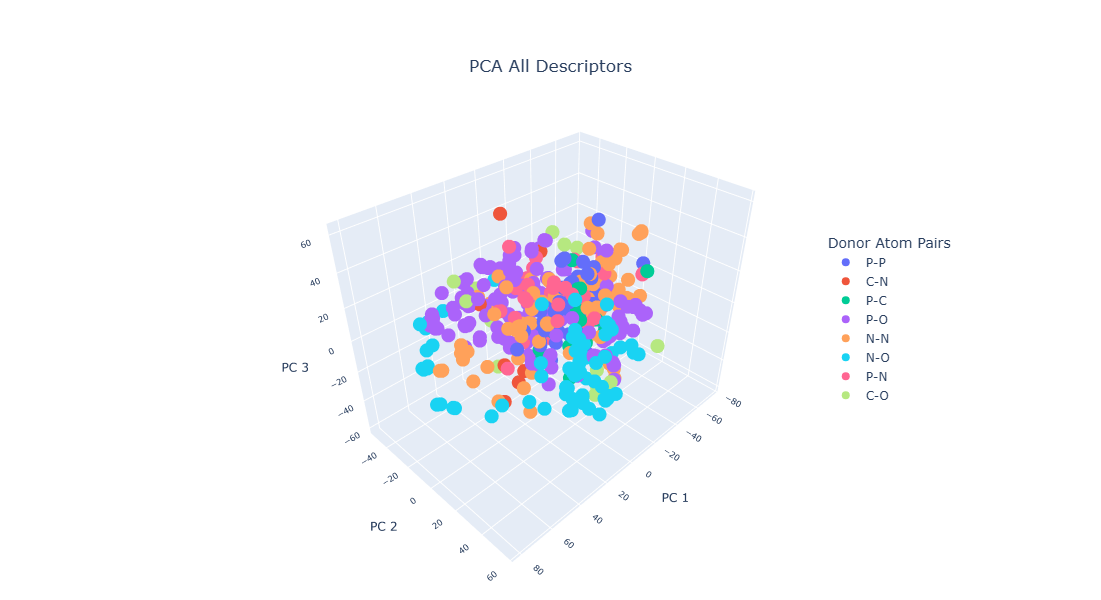

In [18]:
# Generate PCA map with ALL descriptors - find out cluster combinations through this

pca = PCA(n_components=3)
components = pca.fit_transform(X_2)

total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components,
    x=0,
    y=1,
    z=2,
    # text=ligand_id,
    color = donor_atom_comb,
    title=f'PCA All Descriptors',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)

fig.update_layout(width=800, 
                  height=600,
                  margin=dict(l=0, r=0, b=0, t=40),
                  scene=dict(
                    xaxis=dict(title='PC 1', titlefont=dict(size=12), tickfont=dict(size=10)),
                    yaxis=dict(title='PC 2', titlefont=dict(size=12), tickfont=dict(size=10)),
                    zaxis=dict(title='PC 3', titlefont=dict(size=12), tickfont=dict(size=10)),
                    aspectmode='auto',  # Ensures equal aspect ratio for x, y, z axes
                    camera=dict(
                    eye=dict(x=1.5, y=1.5, z=1.5),  # Adjusts the 3D view to see the full plot
                    center=dict(x=0, y=0, z=0),  # Keep camera centered on plot
                    )
                   ),

                  legend=dict(
                      title=dict(text='Donor Atom Pairs'),  # Legend title
                        x=0.75,  # Position the legend closer to the scatter plot horizontally
                        y=0.5,  # Position the legend vertically
                        xanchor='left',
                        yanchor='middle',
                        bgcolor="rgba(255,255,255,0.7)",  # Optional: add semi-transparent background for better visibility
                    ),
                  
                  coloraxis_colorbar=dict(
                  title=dict(text="Percent Buried<br>Volume",
                             side="top"),
                  x=0.8,  # Position the legend closer to the scatter plot
                  y=0.5,
                  xanchor='left',
                  yanchor='middle'),
                  title=dict(
                  x=0.5,          # Horizontal position (centered)
                  y=0.9,          # Vertical position (closer to the plot)
                  xanchor='center',
                  yanchor='top'
                    ) 
                 )
fig.show()

# Save the figure as PNG
fig.write_image("pca_3d_plot_all.png",scale=4)

# Save the figure as HTML
fig.write_html("pca_3d_plot_all.html")

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with M

 - Best Silhouette score: 0.34174638994992196, No. of clusters: 3
 - Best Davies-Bouldin score: 0.944086177967828, No. of clusters: 29
 - Best Calinski-Harabasz score: 282.475957215865, No. of clusters: 3


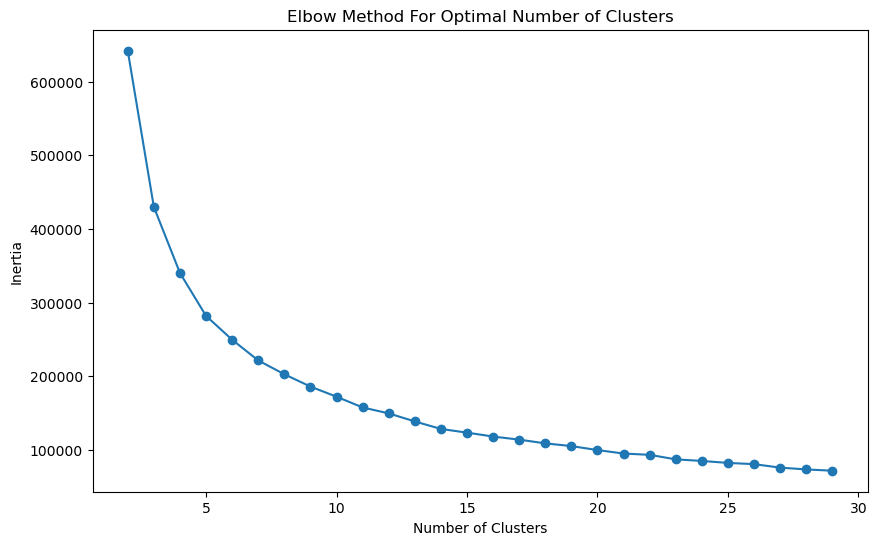

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.




PCA Result DataFrame with Cluster Labels:
           PC1        PC2        PC3  Cluster Ligand
225  27.176708  27.309123   4.930786        0    250
151   1.816586  18.951945  20.611368        0    175
152   1.882202  19.185090  20.981865        0    176
153  32.165588  42.629383  -2.720350        0    177
154  32.646893  44.131050  -2.262516        0    178
..         ...        ...        ...      ...    ...
109  -5.377000 -23.363314  11.652995        2    133
106  18.212676  -7.652150   4.810151        2    130
327  -0.283156 -29.515710   6.331445        2    354
294   6.138044  -0.243678  12.647304        2    321
486  28.831016 -24.575769 -13.202449        2    530

[487 rows x 5 columns]


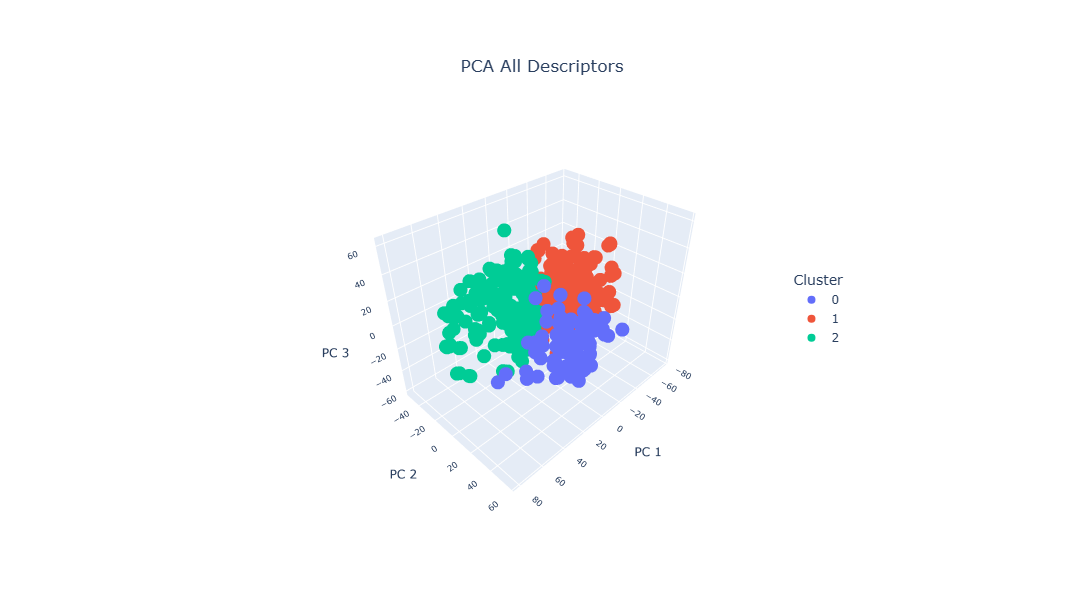

{'c1': ['250', '175', '176', '177', '178', '179', '180', '181', '111', '182', '183', '186', '174', '303', '387', '299', '296', '099', '092', '199', '200', '202', '205', '207', '208', '301', '173', '121', '122', '151', '150', '149', '146', '145', '160', '161', '312', '311', '310', '309', '251', '348', '168', '350', '169', '170', '353', '171', '356', '357', '358', '359', '360', '172', '412', '209', '201', '078', '462', '220', '464', '210', '038', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '490', '237', '238', '239', '240', '241', '263', '259', '257', '254', '252', '528', '219', '456', '221', '218', '211', '455', '074', '075', '072', '212', '213', '214', '073', '443', '451', '076', '077', '216', '217', '215'], 'c2': ['314', '313', '255', '280', '260', '281', '327', '330', '276', '269', '307', '268', '286', '271', '274', '275', '287', '290', '291', '292', '293', '304', '305', '306', '308', '331', nan, '333', '474', '473', '467', '465', '463', '458', '454', '453',

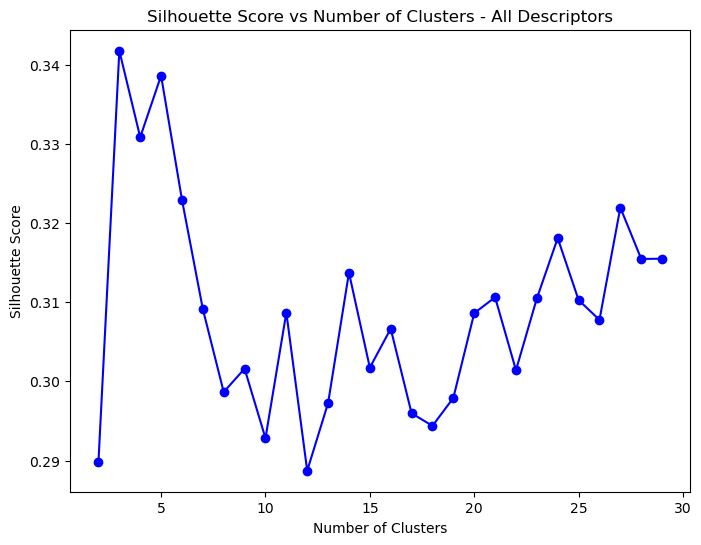

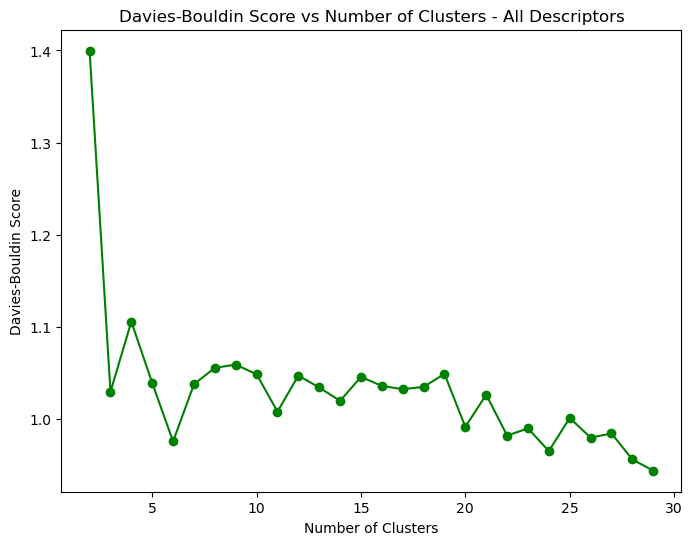

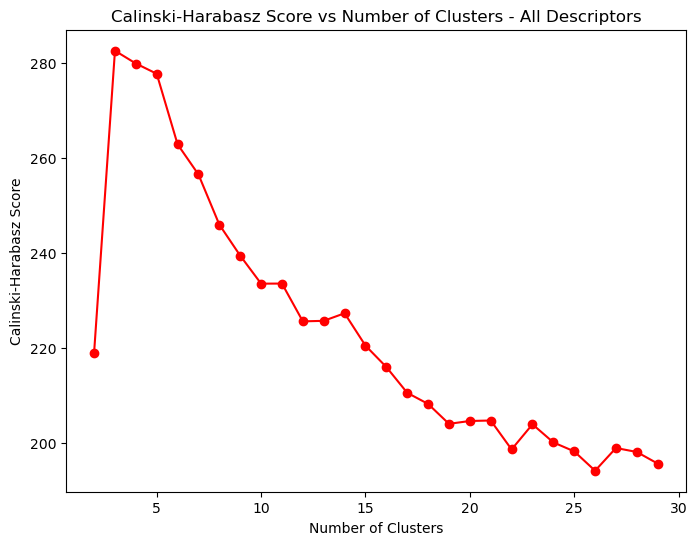

In [19]:
# Generate dataframe from pca data: 
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2','PC3'])

# Apply KMeans Clustering
# Define a range of clusters to evaluate
range_n_clusters = list(range(2, 30))

# Initialize variables to store the best number of clusters and corresponding metrics
best_n_clusters_davies_bouldin = 0
best_n_clusters_silhouette = 0
best_n_clusters_calinski_harabasz = 0
best_silhouette_score = -1
best_davies_bouldin_score = float('inf')
best_calinski_harabasz_score = -1
best_adjusted_rand_score = -1
best_mutual_info_score = -1
inertia = []

# Initialize lists to store the metrics for each number of clusters
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

# Iterate over different cluster numbers to find the optimal number
for n_clusters in range_n_clusters:
    kmeans= KMeans(init="k-means++", n_clusters=n_clusters, n_init=4, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_df)
    
    # Calculate clustering metcis
    silhouette_avg = silhouette_score(pca_df, cluster_labels)
    db_score = davies_bouldin_score(pca_df, cluster_labels)
    ch_score = calinski_harabasz_score(pca_df, cluster_labels)
    inertia.append(kmeans.inertia_)
    
    # Append metrics to corresponding lists
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(db_score)
    calinski_harabasz_scores.append(ch_score)
    
    # Print the scores for the current number of clusters
    # print(f"For n_clusters = {n_clusters}:")
    # print(f" - Silhouette score: {silhouette_avg}")
    # print(f" - Davies-Bouldin score: {db_score}")
    # print(f" - Calinski-Harabasz score: {ch_score}")
    
    # Update the best silhouette score and corresponding number of clusters
    if silhouette_avg > best_silhouette_score:
        best_n_clusters_silhouette = n_clusters
        best_silhouette_score = silhouette_avg

    if db_score < best_davies_bouldin_score:               # Lower Davies-Bouldin score == better
        best_n_clusters_davies_bouldin = n_clusters
        best_davies_bouldin_score = db_score

    if ch_score > best_calinski_harabasz_score:
        best_n_clusters_calinski_harabasz = n_clusters
        best_calinski_harabasz_score = ch_score

# Print the optimal number of clusters and the best silhouette score
print(f" - Best Silhouette score: {best_silhouette_score}, No. of clusters: {best_n_clusters_silhouette}")
print(f" - Best Davies-Bouldin score: {best_davies_bouldin_score}, No. of clusters: {best_n_clusters_davies_bouldin}")
print(f" - Best Calinski-Harabasz score: {best_calinski_harabasz_score}, No. of clusters: {best_n_clusters_calinski_harabasz}")

# Plot the inertia to visualize the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Apply KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=best_n_clusters_silhouette, random_state=42)
cluster_labels = kmeans.fit_predict(pca_df)

# Add cluster labels to the PCA result DataFrame
pca_df['Cluster'] = cluster_labels
pca_df['Ligand'] = X['ligand_id']
pca_df = pca_df.sort_values(by='Cluster')

# Print the PCA result DataFrame with cluster labels
print("\nPCA Result DataFrame with Cluster Labels:")
print(pca_df)

# # Match the rows of X by 'ligand_id' with the order in pca_df['Ligand'], using reindex to handle mismatches
# X_ligand_match = X.set_index('ligand_id').reindex(pca_df['Ligand']).reset_index()

# # Drop rows where there is no matching ligand_id in either X or pca_df
# X_ligand_match = X_ligand_match.dropna()

# X_ligand_match = X.drop(['Name', 'Metal','Atom_A', 'Atom_B','ligand_id','donor_atom_comb'], axis=1)
# print(X_ligand_match)

# Create a dictionary to store clusters and their corresponding ligands
cluster_dict_all_descriptor = {}
for cluster_num in range(best_n_clusters_silhouette):                                             
    cluster_key = f'c{cluster_num + 1}'  # Create cluster key like 'c1', 'c2', etc.
    ligands_in_cluster = pca_df[pca_df['Cluster'] == cluster_num]['Ligand'].tolist()
    cluster_dict_all_descriptor[cluster_key] = ligands_in_cluster

# Visualize PCA with the best number of clusters
# Perform PCA to reduce to 3 dimensions for visualization
# pca = PCA(n_components=3)
# components = pca.fit_transform(X_2)
# print('Components: ', components)

# Calculate the total variance explained by the first 3 components
total_var = pca.explained_variance_ratio_.sum() * 100

# # Create a 3D scatter plot using Plotly, coloring points by cluster labels
# fig = px.scatter_3d(
#     components,
#     x=0,
#     y=1,
#     z=2,
#     color=pca_df['Cluster'].astype(str),  # Convert cluster labels to string for color differentiation
#     # text=pca_df['Ligand'],
#     # title=f'Clustering for all descriptors',
#     labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3', 'color': 'Cluster'}
# )

# Create a 3D scatter plot using Plotly, coloring points by cluster labels
fig = px.scatter_3d(
    pca_df,
    x=pca_df.columns[0],
    y=pca_df.columns[1],
    z=pca_df.columns[2],
    title=f'Clustering for All Descriptors',
    color=pca_df['Cluster'].astype(str),  # Convert cluster labels to string for color differentiation
    # text=pca_df['Ligand'],
    # title=f'Clustering for all descriptors',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3', 'color': 'Cluster'}
)

# Update layout for the 3D scatter plot
fig.update_layout(
    width=800, 
    height=600,
    scene=dict(
    xaxis=dict(title='PC 1', titlefont=dict(size=12), tickfont=dict(size=10)),
    yaxis=dict(title='PC 2', titlefont=dict(size=12), tickfont=dict(size=10)),
    zaxis=dict(title='PC 3', titlefont=dict(size=12), tickfont=dict(size=10)),
    aspectmode='auto',  # Ensures equal aspect ratio for x, y, z axes
    camera=dict(
        eye=dict(x=1.5, y=1.5, z=1.5),  # Increase these values to zoom out
        center=dict(x=0, y=0, z=0),  # Keep camera centered on plot
    )
    ),
    # coloraxis_colorbar=dict(
    #     title=dict(text="Cluster",
    #                side="top"),
    #     x=0.7,  # Position the legend closer to the scatter plot
    #     y=0.5,
    #     xanchor='left',
    #     yanchor='middle'
    # ),
    legend=dict(
        title=dict(text='Cluster'),  # Legend title
        x=0.77,  # Keep the legend to the right of the plot
        y=0.5,  # Move the legend downwards (lower this value more to move further down)
        xanchor='left',
        yanchor='middle',
        bgcolor="rgba(255,255,255,0.7)",  # Optional: add semi-transparent background for better visibility
    ),
    title=dict(
        x=0.5,          # Horizontal position (centered)
        y=0.9,          # Vertical position (closer to the plot)
        xanchor='center',
        yanchor='top'
    )
)

# Show the plot
fig.show()

# Save the figure as PNG
fig.write_image("pca_3d_plot_all_cluster.png",scale=4)

# Save the figure as HTML
fig.write_html("pca_3d_plot_all_cluster.html")

# Print the dictionary
print(cluster_dict_all_descriptor)

# Plot Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, label='Silhouette Score', marker='o', color='blue')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters - All Descriptors')
# Save the figure
plt.savefig("silhouette_score_plot_all.png", format='png', dpi=300)
plt.show()

# Plot Davies-Bouldin Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, davies_bouldin_scores, label='Davies-Bouldin Score', marker='o', color='green')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score vs Number of Clusters - All Descriptors')
plt.savefig("davids_bouldin_plot_all.png", format='png', dpi=300)
plt.show()

# Plot Calinski-Harabasz Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, calinski_harabasz_scores, label='Calinski-Harabasz Score', marker='o', color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score vs Number of Clusters - All Descriptors')
plt.savefig("calinski_harabasz_plot_all.png", format='png', dpi=300)
plt.show()



In [12]:
#Obtain only nbo based descriptor X_nbo
# Obtain only percent buried volume based descriptor X_Vbur 

X_2_columns = X_2.columns
print(X_2_columns)

nbo_list = ['Metal_NBO', 'A_NBO', 'B_NBO', 'HOMO_LUMO', 'A-B_NBO',
       'NBO-dist-2-avg', 'NBO-dist-3-avg', 'NBO-dist-4-avg',
       'NBO-dist-2-a-avg', 'NBO-dist-3-a-avg', 'NBO-dist-4-a-avg',
       'NBO-dist-2-b-avg', 'NBO-dist-3-b-avg', 'NBO-dist-4-b-avg',
       'NBO-dist-2-a-b-diff', 'NBO-dist-3-a-b-diff', 'NBO-dist-4-a-b-diff',
       'NBO-dist-2-min', 'NBO-dist-3-min', 'NBO-dist-4-min', 'NBO-dist-2-max',
       'NBO-dist-3-max', 'NBO-dist-4-max', 'NBO-dist-2-a-min',
       'NBO-dist-3-a-min', 'NBO-dist-4-a-min', 'NBO-dist-2-b-min',
       'NBO-dist-3-b-min', 'NBO-dist-4-b-min', 'NBO-dist-2-a-max',
       'NBO-dist-3-a-max', 'NBO-dist-4-a-max', 'NBO-dist-2-b-max',
       'NBO-dist-3-b-max', 'NBO-dist-4-b-max', 'NBO-metal-donor-diff',
       'NBO-metal-a-diff', 'NBO-metal-b-diff', 'NBO-dist-2-1-avg-diff',
       'NBO-dist-3-2-avg-diff', 'NBO-dist-4-3-avg-diff',
       'NBO-dist-2-1-a-avg-diff', 'NBO-dist-3-2-a-avg-diff',
       'NBO-dist-4-3-a-avg-diff', 'NBO-dist-2-1-b-avg-diff',
       'NBO-dist-3-2-b-avg-diff', 'NBO-dist-4-3-b-avg-diff', 'Metal_mullkien',
       'A_mulliken', 'B_mulliken', 'A-B_mulliken', 'Mulliken-dist-2-avg',
       'Mulliken-dist-3-avg', 'Mulliken-dist-4-avg']


vbur_list = ['Total % VBur', '% VBur SE',
       '% VBur SW', '% VBur NE', '% VBur NW', '% VBur max', '% VBur min',
       '% VBur max min diff', '% VBur NE NW diff', '% VBur SE SW diff',
       '% VBur NE SE diff', '% VBur NW SW diff', '% VBur NE SW diff',
       '% VBur NW SE diff', '% VBur asymm 1', '% VBur asymm 2',
       '% VBur asymm 3', '% VBur octant 1', '% VBur octant 2',
       '% VBur octant 3', '% VBur octant 4', '% VBur octant 5',
       '% VBur octant 6', '% VBur octant 7', '% VBur octant 8']

X_nbo = X_2[nbo_list]
X_vbur = X_2[vbur_list]

Index(['A-M-B Angle', 'M-A Distance', 'M-B Distance', 'Metal_NBO', 'A_NBO',
       'B_NBO', 'HOMO_LUMO', 'A-B_NBO', 'NBO-dist-2-avg', 'NBO-dist-3-avg',
       'NBO-dist-4-avg', 'NBO-dist-2-a-avg', 'NBO-dist-3-a-avg',
       'NBO-dist-4-a-avg', 'NBO-dist-2-b-avg', 'NBO-dist-3-b-avg',
       'NBO-dist-4-b-avg', 'NBO-dist-2-a-b-diff', 'NBO-dist-3-a-b-diff',
       'NBO-dist-4-a-b-diff', 'NBO-dist-2-min', 'NBO-dist-3-min',
       'NBO-dist-4-min', 'NBO-dist-2-max', 'NBO-dist-3-max', 'NBO-dist-4-max',
       'NBO-dist-2-a-min', 'NBO-dist-3-a-min', 'NBO-dist-4-a-min',
       'NBO-dist-2-b-min', 'NBO-dist-3-b-min', 'NBO-dist-4-b-min',
       'NBO-dist-2-a-max', 'NBO-dist-3-a-max', 'NBO-dist-4-a-max',
       'NBO-dist-2-b-max', 'NBO-dist-3-b-max', 'NBO-dist-4-b-max',
       'NBO-metal-donor-diff', 'NBO-metal-a-diff', 'NBO-metal-b-diff',
       'NBO-dist-2-1-avg-diff', 'NBO-dist-3-2-avg-diff',
       'NBO-dist-4-3-avg-diff', 'NBO-dist-2-1-a-avg-diff',
       'NBO-dist-3-2-a-avg-diff', 'NBO-dist

In [20]:
X_vbur

,Total % VBur,% VBur SE,% VBur SW,% VBur NE,% VBur NW,% VBur max,% VBur min,% VBur max min diff,% VBur NE NW diff,% VBur SE SW diff,...,% VBur asymm 2,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8
1,44.968901,41.050130,49.361722,43.838520,45.625233,49.361722,41.050130,8.311592,44.731877,45.205926,...,5.049152,3.262439,81.564480,92.051808,83.060007,82.575475,5.101565,8.190458,6.671636,0.535781
2,47.615193,42.345322,42.617872,52.786060,52.711517,52.786060,42.345322,10.440738,52.748789,42.481597,...,0.099003,0.173546,74.021618,74.375699,95.387626,96.706113,8.866008,10.035408,10.860045,10.669027
3,48.969204,55.339173,57.363492,41.776929,41.397223,57.363492,41.397223,15.966269,41.587076,56.351332,...,0.822307,1.202013,97.623928,96.230898,70.308423,71.878494,11.675363,12.486023,18.496086,13.054417
4,46.750955,37.835445,53.053951,70.816250,25.298174,70.816250,25.298174,45.518077,48.057212,45.444698,...,15.149786,30.368291,64.340291,88.292024,40.775252,96.850540,44.781960,9.821096,17.815878,11.330600
5,42.413460,38.944279,48.327432,56.585445,25.796683,56.585445,25.796683,30.788763,41.191064,43.635855,...,10.702805,20.085958,68.766306,82.636042,51.118151,87.183190,25.987700,0.475214,14.018822,9.122251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,52.486140,64.603522,50.943440,51.945117,42.452479,64.603522,42.452479,22.151044,47.198798,57.773481,...,11.576360,2.083722,95.112747,82.929556,82.789788,89.489378,14.400857,2.115170,18.957324,34.094297
485,39.152767,49.680861,44.542024,36.880358,25.507827,49.680861,25.507827,24.173034,31.194092,47.111442,...,8.255684,3.116847,90.500373,85.370854,51.010995,73.210958,0.549758,0.004659,3.713194,8.861349
486,49.450242,49.312803,66.383246,31.210399,50.894521,66.383246,31.210399,35.172848,41.052460,57.848025,...,18.377283,1.306839,88.883712,99.166045,91.525345,62.350913,0.069884,10.263697,33.600447,9.741893
487,37.815645,48.311126,36.649739,39.305348,26.996366,48.311126,26.996366,21.314760,33.150857,42.480432,...,11.985184,0.323798,87.453410,73.243571,53.922848,77.888558,0.722139,0.069884,0.055908,9.168841


### Generate PCA map with V_bur descriptors - find out cluster combinations through this

In [55]:
A_B_NBO_values = X_nbo['A-B_NBO'].tolist()
float_values = [float(value) for value in A_B_NBO_values]

A_NBO_values = X_nbo['A_NBO'].tolist()
float_values = [float(value) for value in A_NBO_values]

vbur_values = X_vbur['Total % VBur'].tolist()
vbur_values = [float(value) for value in vbur_values]

vbur_max_values = X_vbur['% VBur max'].tolist()
vbur_max_values = [float(value) for value in vbur_max_values]

pca = PCA(n_components=3)
components = pca.fit_transform(X_vbur)

total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components,
    x=0,
    y=1,
    z=2,
    color = donor_atom_comb,
    title=f'PCA VBur Descriptors',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)

fig.update_layout(width=800, 
                  height=600,
                  coloraxis_colorbar=dict(
                  title=dict(text="Percent Buried<br>Volume",
                             side="top"),
                  x=0.85,  # Position the legend closer to the scatter plot
                  y=0.5,
                  xanchor='left',
                  yanchor='middle'),
                  title=dict(
                  x=0.5,          # Horizontal position (centered)
                  y=0.9,          # Vertical position (closer to the plot)
                  xanchor='center',
                  yanchor='top'
                  ),
                  scene_camera=dict(
                  eye=dict(x=1.55, y=1.55, z=0.4)
                  )
                 )
fig.show()
# Save the figure as PNG
fig.write_image("pca_3d_plot_vbur.png",scale=4)

# Save the figure as HTML
fig.write_html("pca_3d_plot_vbur.html")

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with M

 - Best Silhouette score: 0.341340950516204, No. of clusters: 3
 - Best Davies-Bouldin score: 0.9213188167762124, No. of clusters: 26
 - Best Calinski-Harabasz score: 282.10605374378315, No. of clusters: 3


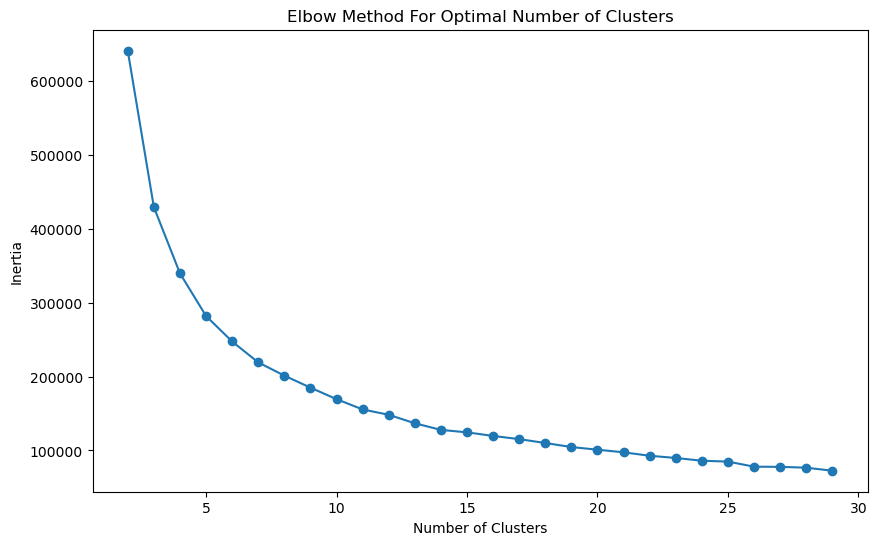

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.




PCA Result DataFrame with Cluster Labels:
           PC1        PC2        PC3  Cluster Ligand
0     0.943312   7.251231  -5.369062        1    NaN
1   -10.374924   3.010404   5.865431        1    002
2   -16.714136  -4.895062  -5.453823        1    003
3    -7.055175 -29.903271 -58.807492        2    004
4    13.306747 -23.945878 -38.986673        2    005
..         ...        ...        ...      ...    ...
482 -32.073700 -21.880579   6.275541        1    526
483  28.386674 -24.799586 -11.415336        2    527
484 -14.925548  29.112600  -5.372391        0    528
485  34.723023 -28.636450  -2.882754        2    529
486  28.805683 -24.420302 -13.238978        2    530

[487 rows x 5 columns]


{'c1': ['038', '072', '073', '074', '075', '076', '077', '078', '092', '099', '111', '121', '122', '145', '146', '149', '150', '151', '160', '161', '168', '169', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '186', '199', '200', '201', '202', '205', '207', '208', '209', '210', '211', '212', '213', '214', '215', '216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '237', '238', '239', '240', '241', '250', '251', '252', '254', '257', '259', '263', '296', '299', '301', '303', '309', '310', '311', '312', '348', '350', '353', '356', '357', '358', '359', '360', '387', '412', '443', '451', '455', '456', '462', '464', '490', '528'], 'c2': [nan, '002', '003', '009', '010', '011', '017', '018', '019', '020', '021', '022', '029', '030', '031', '032', '033', '035', '039', '041', '042', '043', '044', '046', '047', '048', '053', '054', '055', '056', '057', '058', '059', '084', '085', '086',

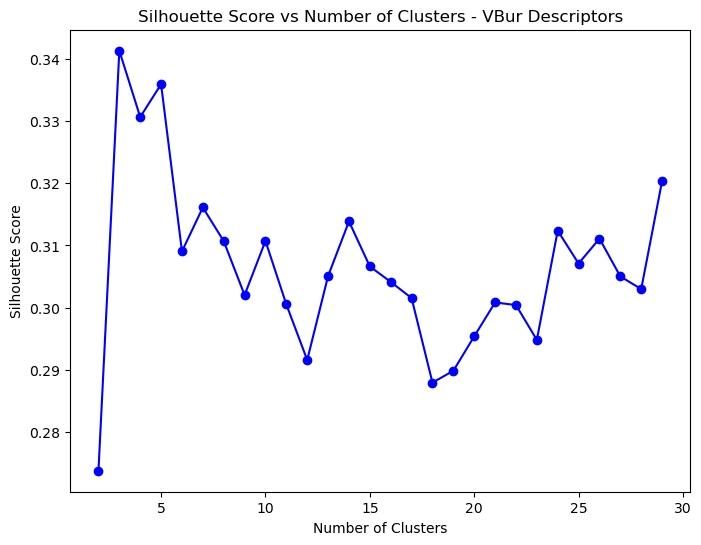

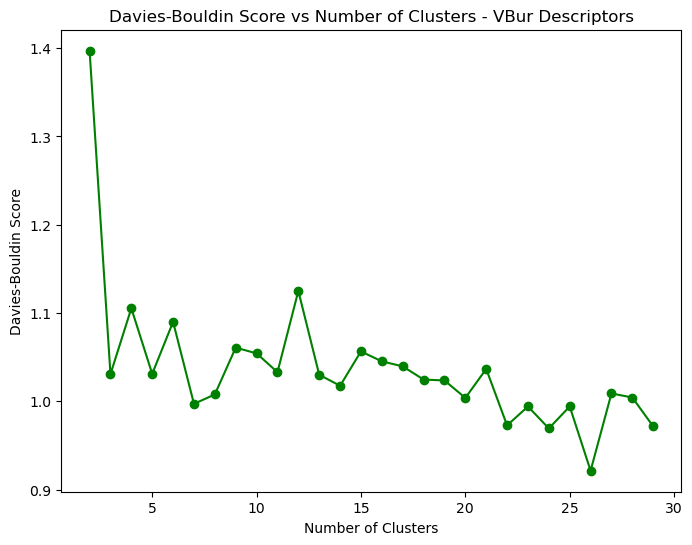

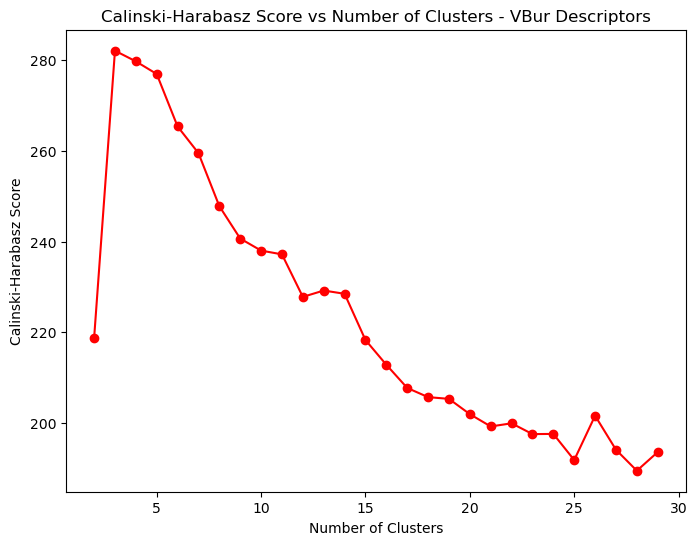

In [54]:
# Generate dataframe from pca data: 
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2','PC3'])

# Apply KMeans Clustering
# Define a range of clusters to evaluate
range_n_clusters = list(range(2, 30))

# Initialize variables to store the best number of clusters and corresponding metrics
best_n_clusters_davies_bouldin = 0
best_n_clusters_silhouette = 0
best_n_clusters_calinski_harabasz = 0
best_silhouette_score = -1
best_davies_bouldin_score = float('inf')
best_calinski_harabasz_score = -1
best_adjusted_rand_score = -1
best_mutual_info_score = -1
inertia = []

# Initialize lists to store the metrics for each number of clusters
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

# Iterate over different cluster numbers to find the optimal number
for n_clusters in range_n_clusters:
    kmeans= KMeans(init="k-means++", n_clusters=n_clusters, n_init=4, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_df)
    
    # Calculate clustering metcis
    silhouette_avg = silhouette_score(pca_df, cluster_labels)
    db_score = davies_bouldin_score(pca_df, cluster_labels)
    ch_score = calinski_harabasz_score(pca_df, cluster_labels)
    inertia.append(kmeans.inertia_)
    
    # Append metrics to corresponding lists
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(db_score)
    calinski_harabasz_scores.append(ch_score)
    
    # Print the scores for the current number of clusters
    # print(f"For n_clusters = {n_clusters}:")
    # print(f" - Silhouette score: {silhouette_avg}")
    # print(f" - Davies-Bouldin score: {db_score}")
    # print(f" - Calinski-Harabasz score: {ch_score}")
    
    # Update the best silhouette score and corresponding number of clusters
    if silhouette_avg > best_silhouette_score:
        best_n_clusters_silhouette = n_clusters
        best_silhouette_score = silhouette_avg

    if db_score < best_davies_bouldin_score:               # Lower Davies-Bouldin score == better
        best_n_clusters_davies_bouldin = n_clusters
        best_davies_bouldin_score = db_score

    if ch_score > best_calinski_harabasz_score:
        best_n_clusters_calinski_harabasz = n_clusters
        best_calinski_harabasz_score = ch_score

# Print the optimal number of clusters and the best silhouette score
print(f" - Best Silhouette score: {best_silhouette_score}, No. of clusters: {best_n_clusters_silhouette}")
print(f" - Best Davies-Bouldin score: {best_davies_bouldin_score}, No. of clusters: {best_n_clusters_davies_bouldin}")
print(f" - Best Calinski-Harabasz score: {best_calinski_harabasz_score}, No. of clusters: {best_n_clusters_calinski_harabasz}")

# Plot the inertia to visualize the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Apply KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=best_n_clusters_silhouette, random_state=42)
cluster_labels = kmeans.fit_predict(pca_df)

# Add cluster labels to the PCA result DataFrame
pca_df['Cluster'] = cluster_labels
pca_df['Ligand'] = X['ligand_id']


# Print the PCA result DataFrame with cluster labels
print("\nPCA Result DataFrame with Cluster Labels:")
print(pca_df)


# Create a dictionary to store clusters and their corresponding ligands
cluster_dict_vbur_descriptor = {}
for cluster_num in range(best_n_clusters_silhouette):                                             
    cluster_key = f'c{cluster_num + 1}'  # Create cluster key like 'c1', 'c2', etc.
    ligands_in_cluster = pca_df[pca_df['Cluster'] == cluster_num]['Ligand'].tolist()
    cluster_dict_vbur_descriptor[cluster_key] = ligands_in_cluster

# Visualize PCA with the best number of clusters
# Perform PCA to reduce to 3 dimensions for visualization
pca = PCA(n_components=3)
components = pca.fit_transform(X_vbur)

# Calculate the total variance explained by the first 3 components
total_var = pca.explained_variance_ratio_.sum() * 100

# Create a 3D scatter plot using Plotly, coloring points by cluster labels
fig = px.scatter_3d(
    components,
    x=0,
    y=1,
    z=2,
    color=pca_df['Cluster'].astype(str),  # Convert cluster labels to string for color differentiation
    title=f'Clustering for VBur Descriptors',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3', 'color': 'Cluster'}
)

# Update layout for the 3D scatter plot
fig.update_layout(
    width=800, 
    height=600,
    coloraxis_colorbar=dict(
        title=dict(text="Cluster",
                   side="top"),
        x=0.85,  # Position the legend closer to the scatter plot
        y=0.5,
        xanchor='left',
        yanchor='middle'
    ),
    title=dict(
        x=0.5,          # Horizontal position (centered)
        y=0.9,          # Vertical position (closer to the plot)
        xanchor='center',
        yanchor='top'
    ),
                  scene_camera=dict(
                  eye=dict(x=1.55, y=1.55, z=0.4)
                  )
)

# Show the plot
fig.show()

# Save the figure as PNG
fig.write_image("pca_3d_plot_vbur_cluster.png",scale=4)

# Save the figure as HTML
fig.write_html("pca_3d_plot_vbur_cluster.html")


# Print the dictionary
print(cluster_dict_vbur_descriptor)

# Plot Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, label='Silhouette Score', marker='o', color='blue')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters - VBur Descriptors')
# Save the figure
plt.savefig("silhouette_score_plot_vbur.png", format='png',dpi=300)
plt.show()


# Plot Davies-Bouldin Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, davies_bouldin_scores, label='Davies-Bouldin Score', marker='o', color='green')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score vs Number of Clusters - VBur Descriptors')
plt.savefig("davies_bouldin_plot_vbur.png", format='png',dpi=300)
plt.show()

# Plot Calinski-Harabasz Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, calinski_harabasz_scores, label='Calinski-Harabasz Score', marker='o', color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score vs Number of Clusters - VBur Descriptors')
plt.savefig("calinski_harabasz_plot_vbur.png.png", format='png',dpi=300)
plt.show()



### Generate PCA map with NBO descriptors - find out cluster combinations through this

In [44]:
A_B_NBO_values = X_nbo['A-B_NBO'].tolist()
float_values = [float(value) for value in A_B_NBO_values]

A_NBO_values = X_nbo['A_NBO'].tolist()
float_values = [float(value) for value in A_NBO_values]


NBO_dist_2_a_b_diff = X_nbo['NBO-dist-2-a-b-diff'].tolist()
NBO_dist_2_a_b_diff = [float(value) for value in NBO_dist_2_a_b_diff]

NBO_dist_3_2_b_avg_diff = X_nbo['NBO-dist-3-2-b-avg-diff'].tolist()
NBO_dist_3_2_b_avg_diff = [float(value) for value in NBO_dist_2_a_b_diff]

vbur_octant_2 = X_2['% VBur octant 2'].tolist()
vbur_octant_2 = [float(value) for value in vbur_octant_2]


#Create PCA Plot in 3D
pca = PCA(n_components=3)
components = pca.fit_transform(X_nbo)

total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components,
    x=0,
    y=1,
    z=2,
    color = donor_atom_comb,
    title=f'PCA NBO Descriptors',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)

fig.update_layout(width=800, 
                  height=600,
                  coloraxis_colorbar=dict(
                  title=dict(text="Percent Buried<br>Volume",
                             side="top"),
                  x=0.85,  # Position the legend closer to the scatter plot
                  y=0.5,
                  xanchor='left',
                  yanchor='middle'),
                  title=dict(
                  x=0.5,          # Horizontal position (centered)
                  y=0.9,          # Vertical position (closer to the plot)
                  xanchor='center',
                  yanchor='top'
                    ),
                    scene_camera=dict(
                    eye=dict(x=1.5, y=1.5, z=0.25)
                    ),
                 )
fig.show()

# Save the figure as PNG
fig.write_image("pca_3d_plot_nbo.png",scale=4)

# Save the figure as HTML
fig.write_html("pca_3d_plot_nbo.html")

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with M

 - Best Silhouette score: 0.7217663396267674, No. of clusters: 4
 - Best Davies-Bouldin score: 0.41631468793832715, No. of clusters: 4
 - Best Calinski-Harabasz score: 4242.748712274995, No. of clusters: 28


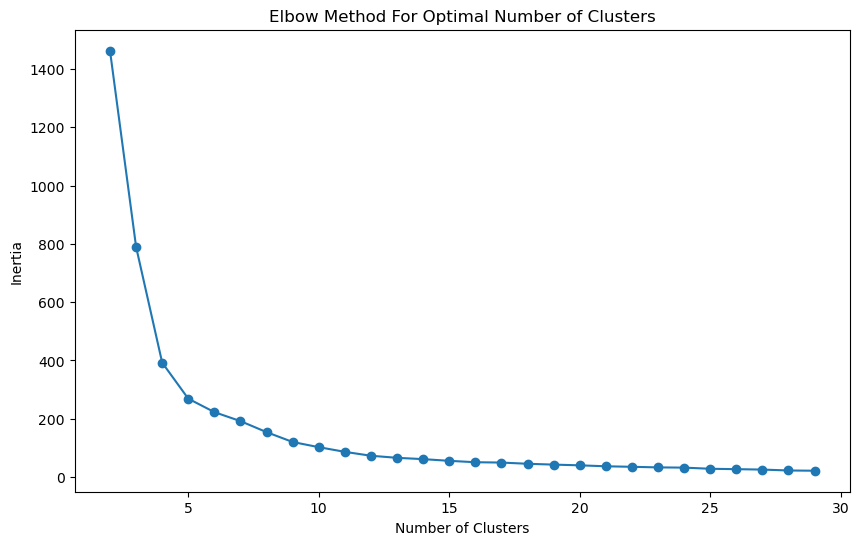

C:\Users\George\.conda\envs\chem3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.




PCA Result DataFrame with Cluster Labels:
          PC1       PC2       PC3  Cluster Ligand
0   -2.715872  1.994140  1.631135        2    NaN
1   -2.717057  1.968486  1.621283        2    002
2   -2.717132  1.936132  1.571325        2    003
3   -1.860836 -0.025780 -0.888367        0    004
4   -1.843924 -0.017406 -0.902588        0    005
..        ...       ...       ...      ...    ...
482  4.766798  1.029991 -1.447404        1    526
483  4.725998  0.999562 -1.421192        1    527
484  4.880784  0.842589 -1.048313        1    528
485  4.740009  1.047778 -1.436801        1    529
486  4.721370  0.985723 -1.417887        1    530

[487 rows x 5 columns]


{'c1': ['004', '005', '006', '007', '008', '009', '010', '060', '071', '072', '073', '074', '075', '076', '077', '078', '112', '113', '114', '115', '116', '129', '139', '140', '141', '142', '145', '146', '147', '148', '149', '150', '151', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '195', '196', '197', '198', '199', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '210', '211', '212', '213', '214', '215', '216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '237', '238', '239', '240', '241', '256', '257', '275', '276', '306', '307', '308', '313', '314', '316', '317', '318', '319', '320', '321', '322', '323', '324', '325', '326', '327', '328', '330', '331', '332', '333', '334', '335', '336', '337', '338', '342', '343', '344', '345', '346', '347', '356', '357', '358', '359', '360', '361', '362', '363'

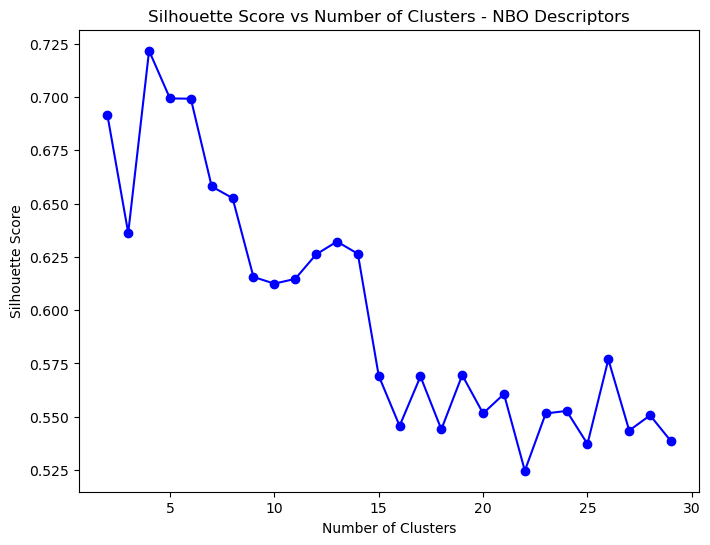

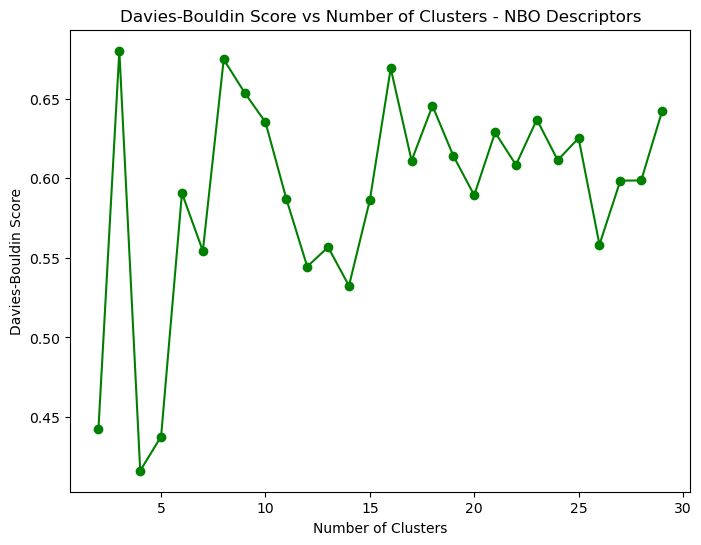

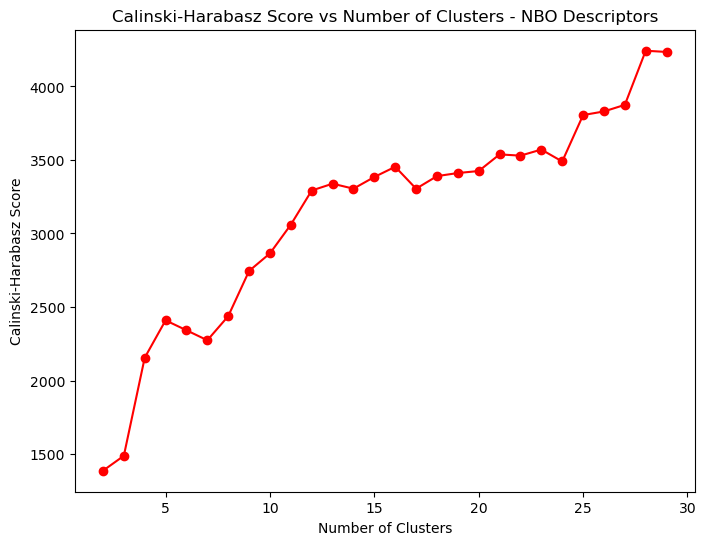

In [43]:
# Generate dataframe from pca data: 
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2','PC3'])

# Apply KMeans Clustering
# Define a range of clusters to evaluate
range_n_clusters = list(range(2, 30))

# Initialize variables to store the best number of clusters and corresponding metrics
best_n_clusters_davies_bouldin = 0
best_n_clusters_silhouette = 0
best_n_clusters_calinski_harabasz = 0
best_silhouette_score = -1
best_davies_bouldin_score = float('inf')
best_calinski_harabasz_score = -1
best_adjusted_rand_score = -1
best_mutual_info_score = -1
inertia = []

# Initialize lists to store the metrics for each number of clusters
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

# Iterate over different cluster numbers to find the optimal number
for n_clusters in range_n_clusters:
    kmeans= KMeans(init="k-means++", n_clusters=n_clusters, n_init=4, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_df)
    
    # Calculate clustering metcis
    silhouette_avg = silhouette_score(pca_df, cluster_labels)
    db_score = davies_bouldin_score(pca_df, cluster_labels)
    ch_score = calinski_harabasz_score(pca_df, cluster_labels)
    inertia.append(kmeans.inertia_)
    
    # Append metrics to corresponding lists
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(db_score)
    calinski_harabasz_scores.append(ch_score)
    
    # Print the scores for the current number of clusters
    # print(f"For n_clusters = {n_clusters}:")
    # print(f" - Silhouette score: {silhouette_avg}")
    # print(f" - Davies-Bouldin score: {db_score}")
    # print(f" - Calinski-Harabasz score: {ch_score}")
    
    # Update the best silhouette score and corresponding number of clusters
    if silhouette_avg > best_silhouette_score:            # Maximize silhouette score
        best_n_clusters_silhouette = n_clusters
        best_silhouette_score = silhouette_avg

    if db_score < best_davies_bouldin_score:               # Lower Davies-Bouldin score == better
        best_n_clusters_davies_bouldin = n_clusters
        best_davies_bouldin_score = db_score

    if ch_score > best_calinski_harabasz_score:           # Maximize calinski harabasz score
        best_n_clusters_calinski_harabasz = n_clusters
        best_calinski_harabasz_score = ch_score

# Print the optimal number of clusters and the best silhouette score
print(f" - Best Silhouette score: {best_silhouette_score}, No. of clusters: {best_n_clusters_silhouette}")
print(f" - Best Davies-Bouldin score: {best_davies_bouldin_score}, No. of clusters: {best_n_clusters_davies_bouldin}")
print(f" - Best Calinski-Harabasz score: {best_calinski_harabasz_score}, No. of clusters: {best_n_clusters_calinski_harabasz}")

# Plot the inertia to visualize the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Apply KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=best_n_clusters_silhouette, random_state=42)
cluster_labels = kmeans.fit_predict(pca_df)

# Add cluster labels to the PCA result DataFrame
pca_df['Cluster'] = cluster_labels
pca_df['Ligand'] = X['ligand_id']


# Print the PCA result DataFrame with cluster labels
print("\nPCA Result DataFrame with Cluster Labels:")
print(pca_df)


# Create a dictionary to store clusters and their corresponding ligands
cluster_dict_nbo_descriptor = {}
for cluster_num in range(best_n_clusters_silhouette):                                             
    cluster_key = f'c{cluster_num + 1}'  # Create cluster key like 'c1', 'c2', etc.
    ligands_in_cluster = pca_df[pca_df['Cluster'] == cluster_num]['Ligand'].tolist()
    cluster_dict_nbo_descriptor[cluster_key] = ligands_in_cluster

# Visualize PCA with the best number of clusters
# Perform PCA to reduce to 3 dimensions for visualization
pca = PCA(n_components=3)
components = pca.fit_transform(X_nbo)

# Calculate the total variance explained by the first 3 components
total_var = pca.explained_variance_ratio_.sum() * 100

# Create a 3D scatter plot using Plotly, coloring points by cluster labels
fig = px.scatter_3d(
    components,
    x=0,
    y=1,
    z=2,
    color=pca_df['Cluster'].astype(str),  # Convert cluster labels to string for color differentiation
    title=f'Clustering for NBO Descriptors',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3', 'color': 'Cluster'}
)

# Update layout for the 3D scatter plot
fig.update_layout(
    width=800, 
    height=600,
    coloraxis_colorbar=dict(
        title=dict(text="Cluster",
                   side="top"),
        x=0.85,  # Position the legend closer to the scatter plot
        y=0.5,
        xanchor='left',
        yanchor='middle'
    ),
    margin=dict(l=40, r=40, t=80, b=120),   # <-- add bottom margin
    scene=dict(
        xaxis_title="PC 1",
        yaxis_title="PC 2",
        zaxis_title="PC 3",
        aspectmode="data",                 # keeps true aspect; optional
        domain=dict(y=[0.12, 1.0])         # leaves ~12% space at bottom; optional
    ),
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=0.25)
    ),
    title=dict(
        x=0.5,          # Horizontal position (centered)
        y=0.9,          # Vertical position (closer to the plot)
        xanchor='center',
        yanchor='top'
    )
)

# Show the plot
fig.show()

# Save the figure as PNG
fig.write_image("pca_3d_plot_nbo_cluster.png",scale=4)

# Save the figure as HTML
fig.write_html("pca_3d_plot_nbo_cluster.html")


# Print the dictionary
print(cluster_dict_nbo_descriptor)

# Plot Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, label='Silhouette Score', marker='o', color='blue')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters - NBO Descriptors')
plt.savefig("silhouette_score_plot_nbo.png", format='png',dpi=300)
plt.show()

# Plot Davies-Bouldin Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, davies_bouldin_scores, label='Davies-Bouldin Score', marker='o', color='green')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score vs Number of Clusters - NBO Descriptors')
plt.savefig("davies_bouldin_plot_plot_nbo.png", format='png',dpi=300)
plt.show()

# Plot Calinski-Harabasz Score
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, calinski_harabasz_scores, label='Calinski-Harabasz Score', marker='o', color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score vs Number of Clusters - NBO Descriptors')
plt.savefig("calinski_harabasz_plot_nbo.png", format='png',dpi=300)
plt.show()



## Store clusters of ligand ids in a .txt file

In [ ]:
import json 

data = {
    'cluster_dict_all_descriptor' : cluster_dict_all_descriptor,
    'cluster_dict_nbo_descriptor' : cluster_dict_nbo_descriptor,
    'cluster_dict_vbur_descriptor' : cluster_dict_vbur_descriptor
    }

# Convert the combined dictionary to a JSON string
json_data = json.dumps(data)

# Write the JSON string to a .txt file
with open('cluster_dictionaries.txt', 'w') as file:
    file.write(json_data)

In [ ]:
cluster_dict_all_descriptor

In [ ]:
cluster_dict_nbo_descriptor

In [ ]:
cluster_dict_vbur_descriptor

In [ ]:
# Function to find the cluster name by number
def find_cluster(number, cluster_dict):
    for cluster_name, numbers in cluster_dict.items():
        if number in numbers:
            return cluster_name
    return "Number not found in any cluster"

# Example usage
number = '241'
cluster_name = find_cluster(number, cluster_dict_all_descriptor)
print(f'The number {number} belongs to cluster: {cluster_name}')